Loaded 13210 trajectories.


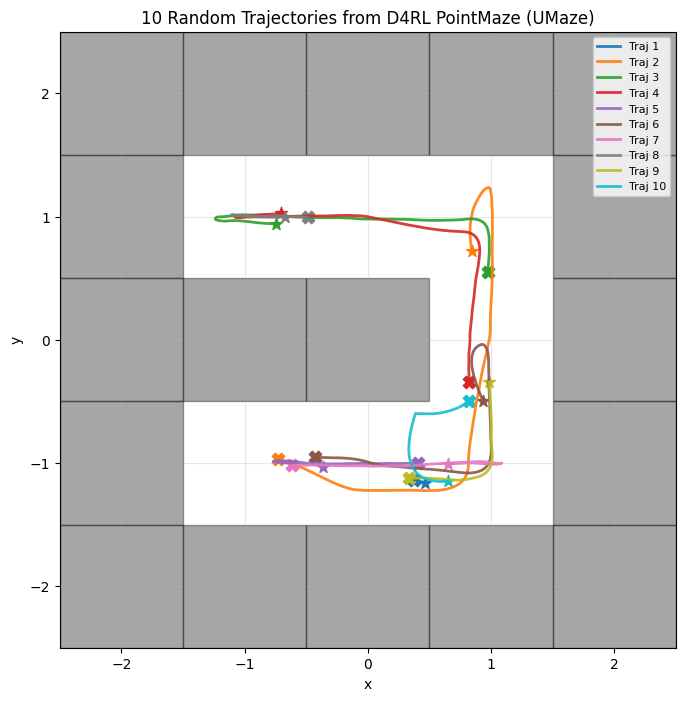

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import minari
import mujoco

# ===========================================================
# Load dataset
# ===========================================================
dataset = minari.load_dataset("D4RL/pointmaze/umaze-v2", download=True)

# Collect all trajectories as (N_i, 2) arrays
trajectories = []
for ep in dataset:
    obs = ep.observations
    if isinstance(obs, dict):
        obs = obs["observation"]
    trajectories.append(obs[:, :2])

print(f"Loaded {len(trajectories)} trajectories.")

# ===========================================================
# Recover MuJoCo env & model for walls
# ===========================================================
env = dataset.recover_environment()

def unwrap_env(env):
    while hasattr(env, "env"):
        env = env.env
    return env

env = unwrap_env(env)
mj_model = env.model

# ===========================================================
# Plot 10 trajectories
# ===========================================================
fig, ax = plt.subplots(figsize=(8, 8))

num_traj = 10
colors = plt.cm.tab10(np.linspace(0, 1, num_traj))

for i in range(num_traj):
    idx = np.random.randint(len(trajectories))
    pos = trajectories[idx]

    # plot dense trajectory
    ax.plot(
        pos[:, 0],
        pos[:, 1],
        linewidth=2,
        color=colors[i],
        alpha=0.9,
        label=f"Traj {i+1}"
    )

    # start and goal
    ax.scatter(pos[0, 0], pos[0, 1], s=80, marker="*", color=colors[i])
    ax.scatter(pos[-1, 0], pos[-1, 1], s=80, marker="X", color=colors[i])

# ===========================================================
# Render MuJoCo maze walls
# ===========================================================
for geom_id in range(mj_model.ngeom):
    name = mujoco.mj_id2name(mj_model, mujoco.mjtObj.mjOBJ_GEOM, geom_id)
    if name is None or ("block" not in name):
        continue

    pos = mj_model.geom_pos[geom_id]
    size = mj_model.geom_size[geom_id]

    cx, cy = pos[:2]
    hx, hy = size[:2]

    ax.add_patch(Rectangle(
        (cx - hx, cy - hy),
        2 * hx,
        2 * hy,
        color="black",
        alpha=0.35,
        zorder=0
    ))

# ===========================================================
# Final styling
# ===========================================================
ax.set_title("10 Random Trajectories from D4RL PointMaze (UMaze)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", "box")
ax.grid(True, alpha=0.3)
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.legend(loc="upper right", fontsize=8)

plt.show()
